# PLS Correlation analysis of resting-state functional connectivity (rsFC)
Maria B. Jelen

In [1]:
# Import packages
import pandas as pd
import os
import numpy as np
import pyls
from matplotlib.colors import ListedColormap
import matplotlib as plt

In [2]:
# Set plotting parameters
plt.rcParams.update({
    "font.family": "Arial",
    "font.weight": "normal"
})

In [3]:
# Check path
import pathlib
notebook_path = pathlib.Path().resolve()
#print(notebook_path)

### PLS Correlation of rsFC and psychopathology profile membership 

In [4]:
# Load data, X = fmri, Y = behavioral
X_df = pd.read_csv('fmri_threshold_80.csv')
Y_df = pd.read_csv('behavioral_matrix_pooled.csv')

In [5]:
# Inspect profile columns
print(Y_df.columns)

Index(['src_subject_id', 'cognitive', 'externalizing', 'high_scores',
       'internalizing', 'noproblems', 'somaticizing', 'withdrawnsocialprob'],
      dtype='object')


In [6]:
from sklearn.preprocessing import StandardScaler


# Sort by ID to ensure same row order
X_df = X_df.sort_values(by='src_subject_id').reset_index(drop=True)
Y_df = Y_df.sort_values(by='src_subject_id').reset_index(drop=True)


# Remove underscores from IDs to match neuroimaging formatting
Y_df['src_subject_id'] = Y_df['src_subject_id'].str.replace('_', '')


# Double-check for NaN values (NaNs removed before)
print(f"Number of NaN values in X_df: {X_df.isna().sum().sum()}")
print(f"Number of NaN values in Y_df: {Y_df.isna().sum().sum()}")

# Separate IDs from data
X_h = X_df.drop('src_subject_id', axis=1).values
Y_h = Y_df.drop('src_subject_id', axis=1).values

# Scale
X_h_scaled = StandardScaler().fit_transform(X_h)
Y_h_scaled = StandardScaler().fit_transform(Y_h)

print(f"Shape of X_scaled: {X_h_scaled.shape}")
print(f"Shape of Y_scaled: {Y_h_scaled.shape}")

Number of NaN values in X_df: 0
Number of NaN values in Y_df: 0
Shape of X_scaled: (4264, 4950)
Shape of Y_scaled: (4264, 7)


In [7]:
# Model of PLSCorrelation
#pls_membership_80_1000it = pyls.behavioral_pls(
#    X_h_scaled, 
#    Y_h_scaled,
#    n_perm=1000,
#    n_boot=1000
#)



# p-values for each latent variable (from permutation testing)
#print("\nP-values for each Latent Variable:")
#print(pls_membership_80_1000it.permres.pvals)

# Covariance explained by each latent variable
#print("\nCovariance Explained by each Latent Variable (%):")
#print(pls_membership_80_1000it.varexp * 100)
#import joblib
# joblib.dump(pls_membership_80_1000it, 'pls_membership_80_1000it.joblib')

In [8]:
import joblib
# load pls_membership_80_1000it model
pls_membership_80_1000it = joblib.load('pls_membership_80_1000it.joblib')

print("\nVariance Explained (%):")
print(pls_membership_80_1000it.varexp * 100)

print("\nP-values:")
print(pls_membership_80_1000it.permres.pvals)


Variance Explained (%):
[28.32386514 18.56936876 15.54025318 12.65198809 12.11816298 11.46792309
  1.32843877]

P-values:
[0.000999   0.01198801 0.08691309 0.34665335 0.63436563 0.72327672
 0.5994006 ]


/var/folders/11/vfl4z8m95mn5h2y8rbf8jfm000075w/T/ipykernel_16323/3925402865.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(clean_labels, fontsize=19, weight = 'bold')
/var/folders/11/vfl4z8m95mn5h2y8rbf8jfm000075w/T/ipykernel_16323/3925402865.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(clean_labels, fontsize=19, weight = 'bold')


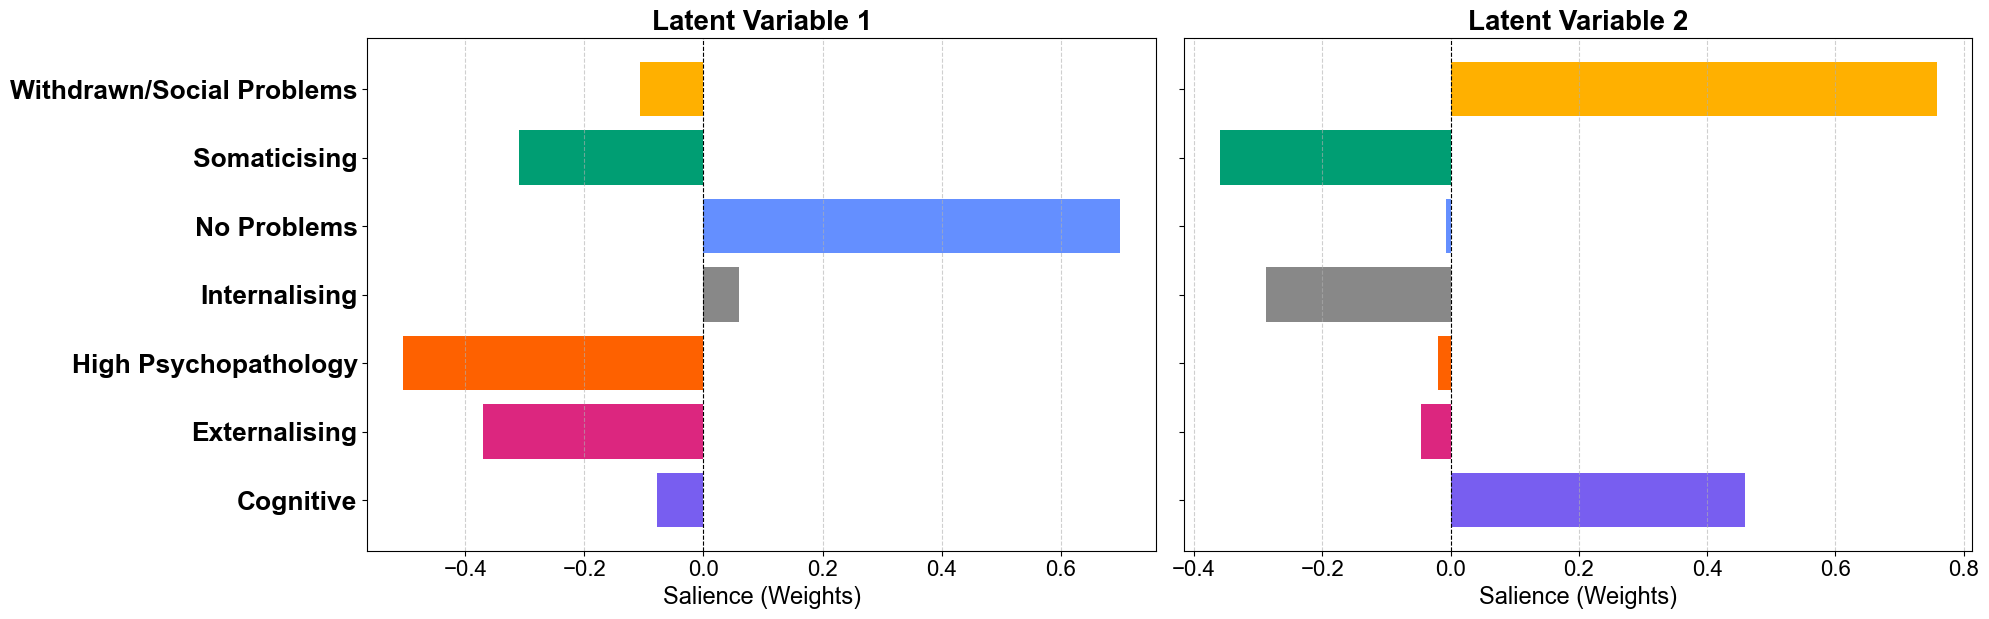

In [9]:
# Plot behavioural group (symptom profile) loadings
import matplotlib.pyplot as plt

ibm_palette = [
    '#785EF0', '#DC267F', '#FE6100','#888888', '#648FFF', '#009E73','#FFB000'
]
label_map = {
    'cognitive' : 'Cognitive',
    'externalizing' : 'Externalising',
    'high_scores' : 'High Psychopathology',
    'internalizing' : 'Internalising',
    'noproblems' : 'No Problems',
    'somaticizing' : 'Somaticising',
    'withdrawnsocialprob' : 'Withdrawn/Social Problems'
}
archetype_specific_colors = dict(zip(label_map.keys(), ibm_palette))

# Set up plot
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 7), sharey=True)

# Labels from the original Y df, dropping ID column
behavioral_labels = Y_df.columns[1:]

# Loop through LV1 and LV2
for i in range(2):
    ax = axes[i]
    
    saliences = pls_membership_80_1000it.y_weights[:, i]
    bar_colors = [archetype_specific_colors.get(name, 'black') for name in behavioral_labels]
    
    ax.barh(behavioral_labels, saliences, color=bar_colors)
    clean_labels = [label_map.get(name, name) for name in behavioral_labels]
    ax.set_yticklabels(clean_labels, fontsize=19, weight = 'bold')

    
    ax.set_title(f"Latent Variable {i+1}", fontsize=20, weight = 'bold')
    ax.set_xlabel("Salience (Weights)", fontsize=17)
    ax.axvline(0, color='black', linestyle='--', linewidth=0.8)
    ax.grid(axis='x', linestyle='--', alpha=0.6)
    ax.tick_params(axis='x', labelsize=16)

axes[0].set_ylabel("", fontsize=14)

fig.suptitle("", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [10]:
# Extract loadings and bootstrap ratios (BSR) for LV1

X_numeric = np.array(X_h, dtype=float)
new_x_loadings = pls_membership_80_1000it['x_weights'].copy()  # shape: (n_edges, n_LVs)
bootstrap_x_loadings = pls_membership_80_1000it['bootres']['x_weights_normed']  # shape: (n_edges, n_LVs)

# Calulate loadings from scores
for lv in range(pls_membership_80_1000it.x_scores.shape[1]):
    for i in range(X_numeric.shape[1]):
      new_x_loadings[i, lv] = np.corrcoef(X_numeric[:, i], pls_membership_80_1000it.x_scores[:, lv])[0, 1]

# Results dataframe with loadings and BSR for LV1      
results_x_loadings_LV1 = pd.DataFrame({
    "Original_x_loadings" : new_x_loadings[:, 0],
    "BSR_LV1" : bootstrap_x_loadings [:, 0]
})


print(new_x_loadings.shape) # shape: (n_edges, n_LVs)

n_nodes = 100
new_loading_matrix_LV1 = np.zeros((n_nodes, n_nodes))
triu_indices = np.triu_indices(n_nodes, k=1)
new_loading_matrix_LV1[triu_indices] = new_x_loadings[:, 0]
new_loading_matrix_LV1 = new_loading_matrix_LV1 + new_loading_matrix_LV1.T  # make symmetric

print(new_loading_matrix_LV1.shape) # expected 100x100 after upper triangle reconstruction for Schaefer-100

# Extract BSR separately and reconstruct as matrix
bsr_matrix_LV1 = np.zeros((n_nodes,n_nodes))
bsr_matrix_LV1[triu_indices] = bootstrap_x_loadings[:, 0]
bsr_matrix_LV1 = bsr_matrix_LV1 + bsr_matrix_LV1.T

(4950, 7)
(100, 100)


In [11]:
# Extract loadings and bootstrap ratios (BSR) for LV2

n_nodes = 100
new_loading_matrix_LV2 = np.zeros((n_nodes, n_nodes))
triu_indices = np.triu_indices(n_nodes, k=1)
new_loading_matrix_LV2[triu_indices] = new_x_loadings[:, 1]
new_loading_matrix_LV2 = new_loading_matrix_LV2 + new_loading_matrix_LV2.T  # make symmetric

print(new_loading_matrix_LV2.shape) # expected 100x100 after upper triangle reconstruction for Schaefer-100


# bsr loadings for plotting

bsr_matrix_LV2 = np.zeros((n_nodes,n_nodes))
bsr_matrix_LV2[triu_indices] = bootstrap_x_loadings[:, 1]
bsr_matrix_LV2 = bsr_matrix_LV2 + bsr_matrix_LV2.T

(100, 100)


### Surface brain plots


In [12]:
# Plot brains using Surfplot in Neuromaps (https://github.com/danjgale/surfplot)

from brainspace.datasets import load_parcellation
atlas = load_parcellation("schaefer", scale=100, join = True)
print(atlas.shape)

from neuromaps.datasets import fetch_fslr
surfaces = fetch_fslr()
lh, rh = surfaces['inflated']

(64984,)


In [13]:
# Custom color mapping
from matplotlib.colors import LinearSegmentedColormap

colors = ["#025358","#238B8B", "#FFFFFFFF","#e07eb0", "#CE0063"]
custom_cmap = LinearSegmentedColormap.from_list("mycmap", colors)

In [14]:
# Define surface function
from surfplot import Plot

def data_to_surfdata(data, atlas, shift=False):
    label_to_data = dict(enumerate(data.flatten(), start=1 if shift else 0))
    surfdata = np.array([label_to_data.get(label, 0) for label in atlas])
    return surfdata

In [15]:
# Uniform size for saving plots
fig_width = 3.0
fig_height = 3.5

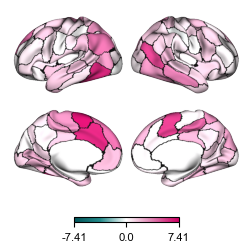

In [16]:
# with significance defined by BSR > 1.96 akin to p < 0.05
# stability mask
stable_conn_LV1 = np.abs(bsr_matrix_LV1) > 1.96

# mask the loadings
masked_loadings_LV1 = np.where(stable_conn_LV1, new_loading_matrix_LV1, 0)
#print(masked_loadings_LV1)

# sum per node
cleaned_strength_LV1 = masked_loadings_LV1.sum(axis=1) 

#for range of connections
abs_max_cleaned_LV1 = np.nanmax(np.abs(cleaned_strength_LV1))

surf_cleaned_strength_LV1 = data_to_surfdata(cleaned_strength_LV1, atlas,shift=True)

p = Plot(surf_lh=lh, surf_rh=rh, brightness=0.8)
p.add_layer(surf_cleaned_strength_LV1, 
cmap=custom_cmap, 
cbar=True,
color_range=(-abs_max_cleaned_LV1, abs_max_cleaned_LV1),
zero_transparent=False)

custom_outline = ListedColormap([ "#000000FF",'#ffffff']) #black outline of regions

p.add_layer(atlas,
cmap=custom_outline,
as_outline=True,
cbar=False)

kws = {'fontsize': 8, 'shrink': 0.45}

fig = p.build(cbar_kws=kws)
fig.set_size_inches(fig_width, fig_height)
#fig.savefig("LV1_thresholded_surfplot.pdf", dpi=600, bbox_inches='tight')   


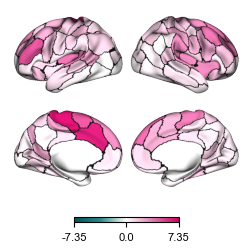

In [36]:
# with significance defined by BSR >= 2
# stability mask
stable_conn_LV2 = np.abs(bsr_matrix_LV2) > 1.96

# mask the loadings
masked_loadings_LV2 = np.where(stable_conn_LV2, new_loading_matrix_LV2, 0)
#print(masked_loadings_LV2)

# sum per node
cleaned_strength_LV2 = masked_loadings_LV2.sum(axis=1)
abs_max_cleaned_LV2 = np.nanmax(np.abs(cleaned_strength_LV2))
surf_cleaned_strength_LV2 = data_to_surfdata(cleaned_strength_LV2, atlas,shift=True)

p = Plot(surf_lh=lh, surf_rh=rh, brightness=0.8)
p.add_layer(surf_cleaned_strength_LV2, 
cmap=custom_cmap, 
cbar=True,
color_range=(-abs_max_cleaned_LV2, abs_max_cleaned_LV2),
zero_transparent=False)

custom_outline = ListedColormap([ "#000000FF",'#ffffff'])  # 0 → white, 1 → dark grey

p.add_layer(atlas,
cmap=custom_outline,
as_outline=True,
cbar=False)

kws = {'fontsize': 8, 'shrink': 0.45}

fig = p.build(cbar_kws=kws)
fig.set_size_inches(fig_width, fig_height)
fig.savefig("LV2_thresholded_surfplot.pdf", dpi=600, bbox_inches='tight') 

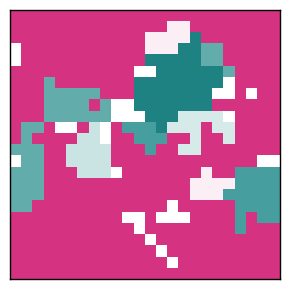

In [ ]:
# Plot of SOM profile regions colored by the LV1 salience

# Import BMUs/locations of psychopathology profiles
import seaborn as sns
import json
from scipy.interpolate import griddata
with open("final_islands_report_split.json", "r") as f:
    island_bmus = json.load(f)

# Max value from mean matrix of loadings
signed_strength_LV1 = new_loading_matrix_LV1.mean(axis=1)

# Order of PLS columns
ordered_names = [
    'simulated_cognitive', 
    'simulated_externalising', 
    'simulated_high_scores', 
    'simulated_internalising', 
    'simulated_noproblems', 
    'simulated_somaticising', 
    'simulated_withdrawnsocialprob'
]

# Extract behavioural saliences (y_loadings) for LV1
lv_idx = 0 # LV1=0
saliences = pls_membership_80_1000it.y_loadings[:, lv_idx]

# Grid for plotting
som_width, som_height = 24, 24
som_matrix = np.zeros((som_height, som_width))
data_mask = np.zeros((som_height, som_width), dtype=bool) # False = No Data

# Mapping based on BMUs of profile
for i, col in enumerate(ordered_names):
    json_key = col
    weight = saliences[i]

    if json_key in island_bmus:
        for cluster in island_bmus[json_key]:
            for node in cluster:
                r,c = node[0], node[1]
                if r<som_height and c<som_width:
                    som_matrix[r, c] = weight
                    data_mask[r, c] = True

# Initiate plot
fig, ax =plt.subplots(figsize=(3.5, 3.5))

# Max value for color mapping
brain_max = np.max(signed_strength_LV1)

# Plot as heatmap
sns.heatmap(
    som_matrix,
    cmap=custom_cmap,
    center=0,
    vmin=-brain_max,
    vmax=brain_max,
    square=True,
    mask=~data_mask,
    cbar=False,
    ax=ax,
    xticklabels=False,
    yticklabels=False
)

# Add border
for _, spine in ax.spines.items():
    spine.set_visible(True)
    spine.set_linewidth(1)
    
plt.show()
fig.set_size_inches(3.5, 3.5)
#fig.savefig("LV1_SOM.jpeg", dpi=600, bbox_inches='tight')   

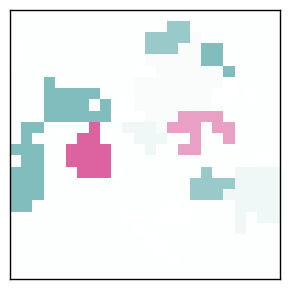

In [ ]:
# Plot of SOM colored by the LV2 salience

# Import BMUs/locations of psychopathology profiles
import json
from scipy.interpolate import griddata
with open("final_islands_report_split.json", "r") as f:
    island_bmus = json.load(f)

# Order of PLS columns
ordered_names = [
    'simulated_cognitive', 
    'simulated_externalising', 
    'simulated_high_scores', 
    'simulated_internalising', 
    'simulated_noproblems', 
    'simulated_somaticising', 
    'simulated_withdrawnsocialprob'
]

# Extract behavioural saliences (y_loadings) for LV2
lv_idx = 1 # LV2=1
saliences = pls_membership_80_1000it.y_loadings[:, lv_idx]

# Grid for plotting
som_width, som_height = 24, 24
som_matrix = np.zeros((som_height, som_width))
data_mask = np.zeros((som_height, som_width), dtype=bool) # False = No Data

# Mapping based on BMUs of profile
for i, col in enumerate(ordered_names):
    json_key = col
    weight = saliences[i]

    if json_key in island_bmus:
        for cluster in island_bmus[json_key]:
            for node in cluster:
                r,c = node[0], node[1]
                if r<som_height and c<som_width:
                    som_matrix[r, c] = weight
                    data_mask[r, c] = True

# Initiate plot
fig, ax =plt.subplots(figsize=(3.5, 3.5))

# Max value for color mapping
brain_max = np.max(signed_strength_LV1)

# Plot as heatmap
sns.heatmap(
    som_matrix,
    cmap=custom_cmap,
    center=0,
    vmin=-brain_max,
    vmax=brain_max,
    square=True,
    mask=~data_mask,
    cbar=False,
    ax=ax,
    xticklabels=False,
    yticklabels=False
)

# Add border
for _, spine in ax.spines.items():
    spine.set_visible(True)
    spine.set_linewidth(1)
    
plt.show()
fig.set_size_inches(3.5, 3.5)
#fig.savefig("LV2_SOM.jpeg", dpi=600, bbox_inches='tight')   

/var/folders/11/vfl4z8m95mn5h2y8rbf8jfm000075w/T/ipykernel_16323/3488853744.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(pretty_labels, fontsize=10, fontname='Arial', weight='bold')
/var/folders/11/vfl4z8m95mn5h2y8rbf8jfm000075w/T/ipykernel_16323/3488853744.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(pretty_labels, fontsize=10, fontname='Arial', weight='bold')


Text(0, 0.5, '')

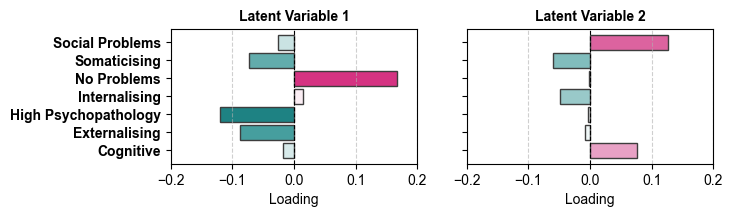

In [34]:
# Alternative behavioural saliences plot 

# Color mapping
import matplotlib.colors as mcolors
colors = ["#025358","#238B8B", "#FFFFFF","#e07eb0", "#CE0063"]
custom_cmap = LinearSegmentedColormap.from_list("mycmap", colors)

# Color limit
limit = brain_max
norm = mcolors.Normalize(vmin=-limit, vmax=limit)

# Neat labels
label_map = {
    'cognitive' : 'Cognitive',
    'externalizing' : 'Externalising',
    'high_scores' : 'High Psychopathology',
    'internalizing' : 'Internalising',
    'noproblems' : 'No Problems',
    'somaticizing' : 'Somaticising',
    'withdrawnsocialprob' : 'Social Problems'
}

# Names from original columns
behavioral_labels = Y_df.columns[1:]

# Initiate plot
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(7,1.75), sharey=True)

for i in range(2):
    ax = axes[i]
    saliences = pls_membership_80_1000it.y_loadings[:, i]
    bar_colors = custom_cmap(norm(saliences))
    ax.barh(behavioral_labels, saliences, color=bar_colors, edgecolor='#3D3D3D', linewidth=1)

    pretty_labels = [label_map.get(name, name) for name in behavioral_labels]
    ax.set_yticklabels(pretty_labels, fontsize=10, fontname='Arial', weight='bold')
    ax.set_title(f"Latent Variable {i+1}", fontsize=10, fontname='Arial', weight='bold')
    ax.set_xlabel("Loading",fontname='Arial', fontsize=10)
    ax.axvline(0, color='black', linestyle='--', linewidth=0.8)
    ax.set_xlim(-0.2,0.2)
    ax.grid(axis='x', linestyle='--', alpha=0.6)
    ax.tick_params(axis='x', labelsize=10)

axes[0].set_ylabel("", fontsize=10)

# Save figure without colorbar
#fig.savefig("Behavior_sal_no_cbar.png", dpi=600, bbox_inches='tight')

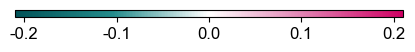

In [ ]:
# Create a separate colorbar to be exported for figure formatting

ticks = np.array([-0.2, -0.1, 0, 0.1, 0.2])

fig_cbar, ax_cbar = plt.subplots(figsize=(5, 0.1))  # width x height in inches
sm = plt.cm.ScalarMappable(cmap=custom_cmap, norm=norm)
sm.set_array([])

cbar = fig_cbar.colorbar(
    sm, 
    cax=ax_cbar, 
    orientation='horizontal'
)
cbar.set_ticks(ticks)
cbar.set_ticklabels([str(t) for t in ticks])
cbar.set_label('', fontname='Arial', weight='bold', fontsize=10)
cbar.ax.tick_params(labelsize=12)

# Save colorbar figure
#fig_cbar.savefig("Behavior_sal_cbar.png", dpi=600, bbox_inches='tight')


### Plotting unique and overlapping edges in LV1 and LV2

In [40]:
# Import Schaefer-100 atlas from nilearn
from nilearn import datasets
from nilearn import plotting

schaefer_atlas = datasets.fetch_atlas_schaefer_2018(n_rois=100, yeo_networks=7)
schaefer_labels = schaefer_atlas.labels
atlas_filename = schaefer_atlas.maps
node_coords = plotting.find_parcellation_cut_coords(labels_img=atlas_filename)


[fetch_atlas_schaefer_2018] Dataset found in /Users/mj03/nilearn_data/schaefer_2018


In [41]:
# Generate matrices for LV1 and LV2 loadings, masked by BSR mask
masked_loadings_LV1 = np.where(stable_conn_LV1, new_loading_matrix_LV1, 0)
masked_loadings_LV2 = np.where(stable_conn_LV2, new_loading_matrix_LV2, 0)

In [42]:
# Define function to remove first node in Schaefer atlas, which is "Background"
def extract_network(label):
    if label == "Background":
        return None
    return label.split("_")[2]

In [44]:
network_colors = {"Vis": "#785EF0",
                  "SomMot": "#000000",
                  "SalVentAttn": "#009E73",
                  "Limbic":"#FE6100",
                  "DorsAttn":"#FFB000",
                  "Default":"#DC267F",
                  "Cont":"#00B8FF"

}

In [46]:
from nichord.convert import convert_matrix
from nichord.chord import plot_chord

# Set up label mapping
idx_to_label = {
    i-1: extract_network(label)
    for i, label in enumerate(schaefer_labels)
    if i != 0
}
idx_to_label = dict(sorted(idx_to_label.items()))

# Define non negative edges from masked matrices
LV1_valid = masked_loadings_LV1 != 0
LV2_valid = masked_loadings_LV2 != 0

# Compute shared and unique edges
shared_weights = np.zeros_like(masked_loadings_LV1)
shared_mask = LV1_valid & LV2_valid
shared_weights[shared_mask] = (masked_loadings_LV1[shared_mask] + masked_loadings_LV2[shared_mask]) / 2

uLV1_weights = np.zeros_like(masked_loadings_LV1)
uLV1_weights[LV1_valid & ~LV2_valid] = masked_loadings_LV1[LV1_valid & ~LV2_valid]

uLV2_weights = np.zeros_like(masked_loadings_LV2)
uLV2_weights[LV2_valid & ~LV1_valid] = masked_loadings_LV2[LV2_valid & ~LV1_valid]

# Plot chord plot
matrices = [
    (shared_weights, 'Chordnew_shared_thresh.png'),
    (uLV1_weights, 'Chordnew_uniqueLV1_thresh.png'),
    (uLV2_weights, 'Chordnew_uniqueLV2_thresh.png')
]

for mat, filename in matrices:
    # Extract raw edges
    e_raw, w_raw = convert_matrix(mat)
    
    # Filter and combine
    edge_dir = sorted([
        ((int(i), int(j)), float(w)) 
        for (i, j), w in zip(e_raw, w_raw) 
        if i != 0 and j != 0
    ])
    
    # Unpack if edge_dir is not empty
    edges = [x[0] for x in edge_dir] if edge_dir else []
    weights = [x[1] for x in edge_dir] if edge_dir else []

    # Plot using sorted idx_to_label
    plot_chord(
        idx_to_label, 
        edges,
        edge_weights=weights,
        network_colors=network_colors,
        linewidths=2,
        alphas=0.7,
        fp_chord=filename
    )
    plt.close('all')

### Post-hoc analysis - GLM

In [ ]:
# GLM model with all covariates: categorical and continuous confounds for LV1

# Prepare package and data
import statsmodels.api as sm
demo_merged = pd.read_csv('demo_merged.csv')
merged_df = pd.merge(X_df, Y_df, on='src_subject_id', how='inner')
final_df = pd.merge(merged_df, demo_merged, on='src_subject_id', how='left')

# Define covariates
cont_cols = ['interview_age', 'rsfmri_meanmotion']
cat_cols = ['sex', 'site_id_l']
confound_cols = cont_cols + cat_cols
# all confounds: 'sex', 'interview_age', 'rsfmri_meanmotion', 'rsfmri_meanrot', 'rsfmri_meantrans', 'site_id_l' 
# 'rsfmri_meanmotion', 'rsfmri_meanrot' and 'rsfmri_meantrans' correlated at ~0.98 so one confound used

confounds_glm = final_df[confound_cols].copy()

x_scores = pls_membership_80_1000it.x_scores
y_scores = pls_membership_80_1000it.y_scores
x_scores_lv1 = x_scores[:, 0]
y_scores_lv1 = y_scores[:, 0]

model_data = confounds_glm
model_data['x_score_lv1'] = x_scores_lv1
model_data['y_score_lv1'] = y_scores_lv1

# Check for NaNs
print(f"Original shape (subjects): {model_data.shape[0]}")
print(f"Missing values:\n{model_data.isnull().sum()}")

# Drop any row that has a NaN
model_data_clean = model_data.dropna().copy()
print(f"\nNew number of subjects after dropping NaNs: {model_data_clean.shape[0]}")

# Ccale only continuous confounds
scaler = StandardScaler()
model_data_clean[cont_cols] = scaler.fit_transform(model_data_clean[cont_cols])

# Dummy code only categorical confounds
model_data_final = pd.get_dummies(
    model_data_clean, 
    columns=cat_cols, 
    drop_first=True,# remove first dummy column to avoid multicollinearity
    dtype=int 
)

# Get the Y variable - y score
y_glm2_lv1 = model_data_final['y_score_lv1']

X_glm2 = model_data_final.drop(columns='y_score_lv1')

# Add intercept
X_glm2_with_const = sm.add_constant(X_glm2)

# Get the list of predictor names for summary
X_glm2_colnames = X_glm2_with_const.columns.tolist()


results2_lv1 = sm.GLM(
    y_glm2_lv1,
    X_glm2_with_const,
    family=sm.families.Gaussian()
).fit(cov_type='HC3')

print(results2_lv1.summary(xname=X_glm2_colnames))

# Package results
export_df_LV1 = pd.DataFrame({
    "coef": results2_lv1.params,
    "std_err": results2_lv1.bse,
    "z_value": results2_lv1.tvalues,  # tvalues works for Gaussian GLM
    "p_value": results2_lv1.pvalues,
    "CI_lower": results2_lv1.conf_int()[0],
    "CI_upper": results2_lv1.conf_int()[1]
})

# Reset index to have predictor names as a column
export_df_LV1 = export_df_LV1.reset_index().rename(columns={"index": "predictor"})

# Export to CSV
export_df_LV1.to_csv("GLM_results_LV1.csv", index=False)

Original shape (subjects): 4264
Missing values:
interview_age        12
rsfmri_meanmotion    25
sex                  12
site_id_l            12
x_score_lv1           0
y_score_lv1           0
dtype: int64

New number of subjects after dropping NaNs: 4239
                 Generalized Linear Model Regression Results                  
Dep. Variable:            y_score_lv1   No. Observations:                 4239
Model:                            GLM   Df Residuals:                     4212
Model Family:                Gaussian   Df Model:                           26
Link Function:               Identity   Scale:                          1.5513
Method:                          IRLS   Log-Likelihood:                -6931.9
Date:                Wed, 22 Apr 2026   Deviance:                       6533.9
Time:                        16:05:13   Pearson chi2:                 6.53e+03
No. Iterations:                     3   Pseudo R-squ. (CS):            0.05579
Covariance Type:                  

In [ ]:
# GLM model with all covariates: categorical and continuous confounds for LV2
cont_cols = ['interview_age', 'rsfmri_meanmotion']
cat_cols = ['sex', 'site_id_l']
confound_cols = cont_cols + cat_cols
# all confounds: 'sex', 'interview_age', 'rsfmri_meanmotion', 'rsfmri_meanrot', 'rsfmri_meantrans', 'site_id_l' 
# 'rsfmri_meanmotion', 'rsfmri_meanrot' and 'rsfmri_meantrans' correlated at ~0.98 so one confound used

confounds_glm = final_df[confound_cols].copy()

x_scores = pls_membership_80_1000it.x_scores
y_scores = pls_membership_80_1000it.y_scores
x_scores_lv2 = x_scores[:, 1]
y_scores_lv2 = y_scores[:, 1]

model_data = confounds_glm
model_data['x_score_lv2'] = x_scores_lv2
model_data['y_score_lv2'] = y_scores_lv2

# Check for NaNs
print(f"Original shape (subjects): {model_data.shape[0]}")
print(f"Missing values:\n{model_data.isnull().sum()}")

# Drop any row that has a NaN
model_data_clean = model_data.dropna().copy()
print(f"\nNew number of subjects after dropping NaNs: {model_data_clean.shape[0]}")

# Scale only continuous confounds
scaler = StandardScaler()
model_data_clean[cont_cols] = scaler.fit_transform(model_data_clean[cont_cols])

# Dummy code only categorical confounds
model_data_final = pd.get_dummies(
    model_data_clean, 
    columns=cat_cols, 
    drop_first=True,# remove first dummy column to avoid multicollinearity
    dtype=int 
)

# Get the Y variable - y score
y_glm2_lv2 = model_data_final['y_score_lv2']

X_glm2_lv2 = model_data_final.drop(columns='y_score_lv2')

# Add intercept
X_glm2_with_const_lv2 = sm.add_constant(X_glm2_lv2)

# Get the list of predictor names for summary
X_glm2_colnames_lv2 = X_glm2_with_const_lv2.columns.tolist()

results2_lv2 = sm.GLM(
    y_glm2_lv2,
    X_glm2_with_const_lv2,
    family=sm.families.Gaussian()
).fit(cov_type='HC3')

print(results2_lv2.summary())

# Package results
export_df_LV2 = pd.DataFrame({
    "coef": results2_lv2.params,
    "std_err": results2_lv2.bse,
    "z_value": results2_lv2.tvalues,  # tvalues works for Gaussian GLM
    "p_value": results2_lv2.pvalues,
    "CI_lower": results2_lv2.conf_int()[0],
    "CI_upper": results2_lv2.conf_int()[1]
})
export_df_LV2 = export_df_LV2.reset_index().rename(columns={"index": "predictor"})

# Export to CSV
export_df_LV2.to_csv("GLM_results_LV2.csv", index=False)


Original shape (subjects): 4264
Missing values:
interview_age        12
rsfmri_meanmotion    25
sex                  12
site_id_l            12
x_score_lv2           0
y_score_lv2           0
dtype: int64

New number of subjects after dropping NaNs: 4239
                 Generalized Linear Model Regression Results                  
Dep. Variable:            y_score_lv2   No. Observations:                 4239
Model:                            GLM   Df Residuals:                     4212
Model Family:                Gaussian   Df Model:                           26
Link Function:               Identity   Scale:                         0.99085
Method:                          IRLS   Log-Likelihood:                -5981.8
Date:                Wed, 22 Apr 2026   Deviance:                       4173.4
Time:                        16:05:23   Pearson chi2:                 4.17e+03
No. Iterations:                     3   Pseudo R-squ. (CS):            0.03726
Covariance Type:                  

In [ ]:
# fMRI motion measures usually correlated - check correlation
motion_cols = ['rsfmri_meanmotion', 'rsfmri_meanrot', 'rsfmri_meantrans']
motion_df = final_df[motion_cols]
corr_matrix = motion_df.corr()

print("Correlation matrix for motion parameters:")
print(corr_matrix)

Correlation matrix for motion parameters:
                   rsfmri_meanmotion  rsfmri_meanrot  rsfmri_meantrans
rsfmri_meanmotion           1.000000        0.977429          0.979740
rsfmri_meanrot              0.977429        1.000000          0.915314
rsfmri_meantrans            0.979740        0.915314          1.000000
